# Distance from Data Center Facilities to Tribal Land

For each data center facility with known coordinates, computes distance to the nearest tribal land boundary (Census TIGER AIANNH shapefile) using a proper equal-area projection. Run against the real facility list and Census shapefile. Includes a data-quality fix: a handful of real rows had non-numeric garbage in the Longitude column (e.g. 'YES  MAJOR'), so this run adds explicit numeric coercion before filtering, which the original script didn't have.

### Setup and load real data

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

# ── ASSUMPTIONS ──────────────────────────────────────────────────────────────
# dc:           dc_merged dataframe, columns: Latitude, Longitude
# tribal_gdf:  GeoDataFrame loaded from the Census TIGER AIANNH shapefile, e.g.:
#              tribal_gdf = gpd.read_file("tl_2025_us_aiannh.shp")
# ─────────────────────────────────────────────────────────────────────────────
dc=pd.read_csv("DC_List (merge) files/dc_merged_updated_with_dates.csv", encoding='latin-1')
tribal_gdf = gpd.read_file("Distance_to_variables/tl_2025_us_aiannh/tl_2025_us_aiannh.shp") 

### Clean coordinates, reproject, dissolve tribal polygons (steps 1-4)

In [2]:
# 1. Drop DC facilities missing or non-numeric coordinates (a handful of rows have
#    garbage strings in Latitude/Longitude, e.g. data-entry errors like "YES  MAJOR")
dc['Latitude'] = pd.to_numeric(dc['Latitude'], errors='coerce')
dc['Longitude'] = pd.to_numeric(dc['Longitude'], errors='coerce')
dc_geo = dc[dc['Latitude'].notna() & dc['Longitude'].notna()].copy()
print(f"DC facilities with coords: {len(dc_geo)}")

# 2. Convert dc_geo to GeoDataFrame (WGS84)
dc_gdf = gpd.GeoDataFrame(
    dc_geo,
    geometry=gpd.points_from_xy(dc_geo['Longitude'], dc_geo['Latitude']),
    crs='EPSG:4326'
)

# 3. Reproject both to a meters-based CRS for accurate distance measurement
#    EPSG:5070 = Albers Equal Area Conic (contiguous US standard)
dc_proj     = dc_gdf.copy().to_crs('EPSG:5070')
tribal_proj = tribal_gdf.to_crs('EPSG:5070')

# 4. Dissolve tribal polygons into a single geometry (speeds up distance query)
tribal_union = tribal_proj.geometry.union_all()

DC facilities with coords: 1277


### Compute distance and flag facilities within tribal land (steps 5-8)

In [3]:
# 5. Compute distance from each facility to nearest tribal land boundary (meters)
print("Computing distances... (this may take a minute)")
dc_proj['dist_tribal_land_m'] = dc_proj.geometry.apply(
    lambda pt: pt.distance(tribal_union)
)

# 6. Convert to miles
dc_proj['dist_tribal_land_miles'] = dc_proj['dist_tribal_land_m'] / 1609.344

# 7. Flag facilities inside tribal land (distance == 0)
dc_proj['within_tribal_land'] = dc_proj['dist_tribal_land_m'] == 0

# 8. Find name of nearest tribal area for reference
print("Finding nearest tribal area names...")
def nearest_tribal_name(pt):
    dists = tribal_proj.geometry.distance(pt)
    return tribal_proj.loc[dists.idxmin(), 'NAMELSAD']  # adjust col name if needed

dc_proj['nearest_tribal_area'] = dc_proj.geometry.apply(nearest_tribal_name)

Computing distances... (this may take a minute)


Finding nearest tribal area names...


### Merge results and summarize (steps 9-10)

In [4]:
# 9. Merge results back onto full dc dataframe
result_cols = ['dist_tribal_land_m', 'dist_tribal_land_miles',
               'within_tribal_land', 'nearest_tribal_area']

dc_out = dc.merge(
    dc_proj[result_cols],
    left_index=True, right_index=True, how='left'
)

# 10. Summary
print(f"\nDistance to tribal land summary (miles):")
print(dc_out['dist_tribal_land_miles'].describe().round(3))
print(f"\nFacilities within tribal land: {dc_out['within_tribal_land'].sum()}")
print(f"\nSample output:")
print(dc_out[['Facility_Name', 'dist_tribal_land_miles',
              'within_tribal_land', 'nearest_tribal_area']].head(10).to_string())

dc_distance_to_tribal_land= dc_out[[ 'Facility_number', 'Facility_Name', 'State', 'County', 'Street_Address', 'Zip', 'Latitude', 'Longitude', 'dist_tribal_land_miles', 'within_tribal_land', 'nearest_tribal_area']]
dc_distance_to_tribal_land.to_csv("Distance_to_variables/dc_with_tribal_land_distance.csv", index=False)      


Distance to tribal land summary (miles):
count    1277.000
mean       69.640
std       133.253
min         0.000
25%        32.663
50%        57.083
75%        79.301
max      4498.639
Name: dist_tribal_land_miles, dtype: float64

Facilities within tribal land: 9

Sample output:
                                                                               Facility_Name  dist_tribal_land_miles within_tribal_land                                           nearest_tribal_area
0                      Provident Realty Burns Harbor (100 Worthington Dr, Porter County, IN)               23.388788              False                                           Pokagon Reservation
1            36MW Boutique Data Center Campus (140 W 5th Ave, Naperville, DuPage County, IL)               35.900001              False  Prairie Band of Potawatomi Nation Off-Reservation Trust Land
2                                        1977 Saturn Data Center (HMC Capital / DigiCo LAX1)               50.556086         

## Visualization

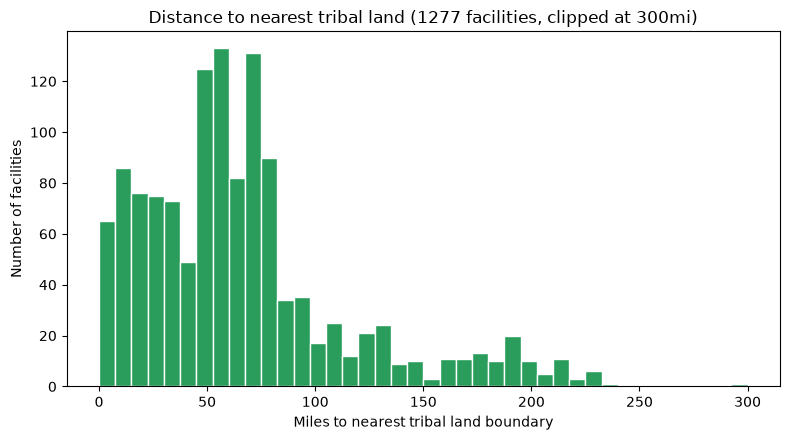

9 facilities sit within tribal land boundaries (distance = 0).


In [5]:

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10



import pandas as pd
df = pd.read_csv("Distance_to_variables/dc_with_tribal_land_distance.csv")
d = df["dist_tribal_land_miles"].dropna()
within = int(df["within_tribal_land"].sum())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(d.clip(upper=300), bins=40, color="#2a9d5c", edgecolor="white")
ax.set_title(f"Distance to nearest tribal land ({len(d)} facilities, clipped at 300mi)")
ax.set_xlabel("Miles to nearest tribal land boundary")
ax.set_ylabel("Number of facilities")
plt.tight_layout()
plt.show()
print(f"{within} facilities sit within tribal land boundaries (distance = 0).")
